# <p style="text-align: center; color: #2E86C1; font-family: 'Segoe UI', Arial; font-weight: bold; font-size: 32px; margin-bottom: 0px;">📊 WEB TRAFFIC DATA ANALYTICS REPORT</p>
### <p style="text-align: center; color: #3498DB; font-family: 'Segoe UI', Arial; margin-top: 5px;">Week 9: Python for Visualization & Reporting</p>

---

<div style="background-color: #EBF5FB; padding: 20px; border-radius: 10px; border-left: 8px solid #2E86C1;">

### 👥 Project Team: Data Drifters
* 👤 **Thato Msina**
* 👤 **Fikile Noyila**
* 👤 **Lesedi Mphachake**
* 👤 **Jereshan Sinan**
* 👤 **Kaylene Martins**

</div>

---

### 📖 1. Project Overview
This report documents our analytical journey into the **WebTraffic Dataset**. Our goal is to transform raw web traffic data into meaningful visual stories and automated reports. Using **Python**, we will generate traffic trend plots to understand user behavior, page performance, and source effectiveness. Finally, we will automate the generation of this analysis into easily distributable PDF and HTML formats.

### 🛠️ Technology Stack
* **Language:** Python 3 (Data Analysis & Scripting)
* **Library:** Pandas (Data Manipulation)
* **Library:** Matplotlib, Seaborn & Plotly (Visualization & Trend Plotting)
* **Output:** Jupyter Notebook, HTML, and PDF (Automated Reporting)

---

### 📑 Table of Contents
| Section | Description |
| :--- | :--- |
| [🚀 1. Data Loading & Inspection](#data-loading) | Importing the WebTraffic dataset and exploring its structure. |
| [📊 2. Traffic Trend Visualizations](#visualizations) | Generating static and interactive plots (Matplotlib, Seaborn, Plotly) to analyze visits, bounce rates, and traffic sources. |
| [⚙️ 3. Automating Reports](#automating-reports) | Exporting the completed analysis and visuals into HTML and PDF formats for stakeholder review. |

---

In [1]:
# ============================================================
#  📦 CELL 1: Install Required Libraries & Import Everything
#  We begin our journey by gathering our tools.
#  Think of this as a data analyst packing their toolkit
#  before heading into the field.
# ============================================================

# Install libraries not pre-installed in Colab
!pip install plotly kaleido fpdf2 --quiet

# --- Standard Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# --- Reporting Libraries ---
from fpdf import FPDF
from IPython.display import display, HTML, FileLink
import warnings
import os

warnings.filterwarnings("ignore")

# --- Global Style Settings ---
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("✅ All libraries loaded successfully!")
print("🚀 Ready to begin the Web Traffic Story...")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 889.5 kB/s eta 0:00:00
✅ All libraries loaded successfully!
🚀 Ready to begin the Web Traffic Story...


In [3]:
# ============================================================
#  📂 CELL 2: Upload & Load the Dataset
#
#  Every great story starts with a dataset.
#  Our dataset — WebTraffic.csv — is a week's worth of
#  digital footprints left by visitors on a website.
#  Let's load it and take our first look.
# ============================================================

from google.colab import files

print("📤 Please upload your WebTraffic.csv file...")
uploaded = files.upload()


# Load the dataset
df = pd.read_csv("WebTraffic.csv")


# Parse date column
df['date'] = pd.to_datetime(df['date'])

# Preview
print("\n" + "="*60)
print("       🌐 WEBTRAFFIC DATASET — FIRST LOOK")
print("="*60)
display(df.head(10).style
        .background_gradient(cmap='Blues', subset=['visits', 'unique_visitors'])
        .format({'bounce_rate': '{:.0%}', 'visits': '{:,}', 'unique_visitors': '{:,}'})
        .set_caption("📋 Sample of WebTraffic Data"))

print(f"\n📊 Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📅 Date Range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"📄 Pages Tracked : {df['page'].unique().tolist()}")
print(f"🔀 Traffic Sources: {df['source'].unique().tolist()}")

📤 Please upload your WebTraffic.csv file...


Saving WebTraffic.csv to WebTraffic.csv

       🌐 WEBTRAFFIC DATASET — FIRST LOOK


,date,page,source,visits,unique_visitors,bounce_rate
0,2025-10-13 00:00:00,Home,Direct,180,150,42%
1,2025-10-13 00:00:00,Home,Search,220,200,35%
2,2025-10-13 00:00:00,Home,Social,90,80,48%
3,2025-10-13 00:00:00,Home,Referral,60,55,40%
4,2025-10-13 00:00:00,Courses,Direct,95,82,38%
5,2025-10-13 00:00:00,Courses,Search,140,120,33%
6,2025-10-13 00:00:00,Blog,Search,110,100,50%
7,2025-10-13 00:00:00,Contact,Direct,45,43,30%
8,2025-10-13 00:00:00,Admissions,Search,70,65,32%
9,2025-10-14 00:00:00,Home,Direct,170,145,44%



📊 Dataset Shape : 63 rows × 6 columns
📅 Date Range    : 2025-10-13 → 2025-10-19
📄 Pages Tracked : ['Home', 'Courses', 'Blog', 'Contact', 'Admissions']
🔀 Traffic Sources: ['Direct', 'Search', 'Social', 'Referral']


In [4]:
# ============================================================
#  🧹 CELL 3: Data Cleaning & Summary Statistics
#
#  Before we visualize, we clean.
#  A good analyst never trusts raw data blindly.
#  We check for missing values, duplicates, and data types —
#  because the truth is only as good as the data behind it.
# ============================================================

print("="*60)
print("       🔍 DATA QUALITY REPORT")
print("="*60)

# Missing values
missing = df.isnull().sum()
print(f"\n🚨 Missing Values:\n{missing}")

# Duplicates
dupes = df.duplicated().sum()
print(f"\n🔁 Duplicate Rows: {dupes}")

# Data types
print(f"\n🗂️  Data Types:\n{df.dtypes}")

# Summary statistics
print("\n" + "="*60)
print("       📈 SUMMARY STATISTICS")
print("="*60)
summary = df.select_dtypes(include=np.number).describe().T
display(summary.style
        .background_gradient(cmap='YlOrRd', subset=['mean', 'max'])
        .format(precision=2)
        .set_caption("📊 Descriptive Statistics for Numeric Columns"))

# Add derived columns for enriched analysis
df['conversion_proxy'] = (df['unique_visitors'] / df['visits']).round(2)
df['engagement_score'] = ((1 - df['bounce_rate']) * df['visits']).round(0)
df['day_of_week'] = df['date'].dt.day_name()

print("\n✅ Data is clean! New columns added:")
print("   → 'conversion_proxy'  : Ratio of unique visitors to total visits")
print("   → 'engagement_score'  : Visits weighted by engagement (1 - bounce rate)")
print("   → 'day_of_week'       : Day name extracted from date")

       🔍 DATA QUALITY REPORT

🚨 Missing Values:
date               0
page               0
source             0
visits             0
unique_visitors    0
bounce_rate        0
dtype: int64

🔁 Duplicate Rows: 0

🗂️  Data Types:
date               datetime64[ns]
page                       object
source                     object
visits                      int64
unique_visitors             int64
bounce_rate               float64
dtype: object

       📈 SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
visits,63.00,118.63,61.06,36.00,73.50,105.00,152.50,260.00
unique_visitors,63.00,105.78,53.43,34.00,68.00,90.00,135.00,235.00
bounce_rate,63.00,0.38,0.07,0.28,0.32,0.36,0.44,0.50



✅ Data is clean! New columns added:
   → 'conversion_proxy'  : Ratio of unique visitors to total visits
   → 'engagement_score'  : Visits weighted by engagement (1 - bounce rate)
   → 'day_of_week'       : Day name extracted from date


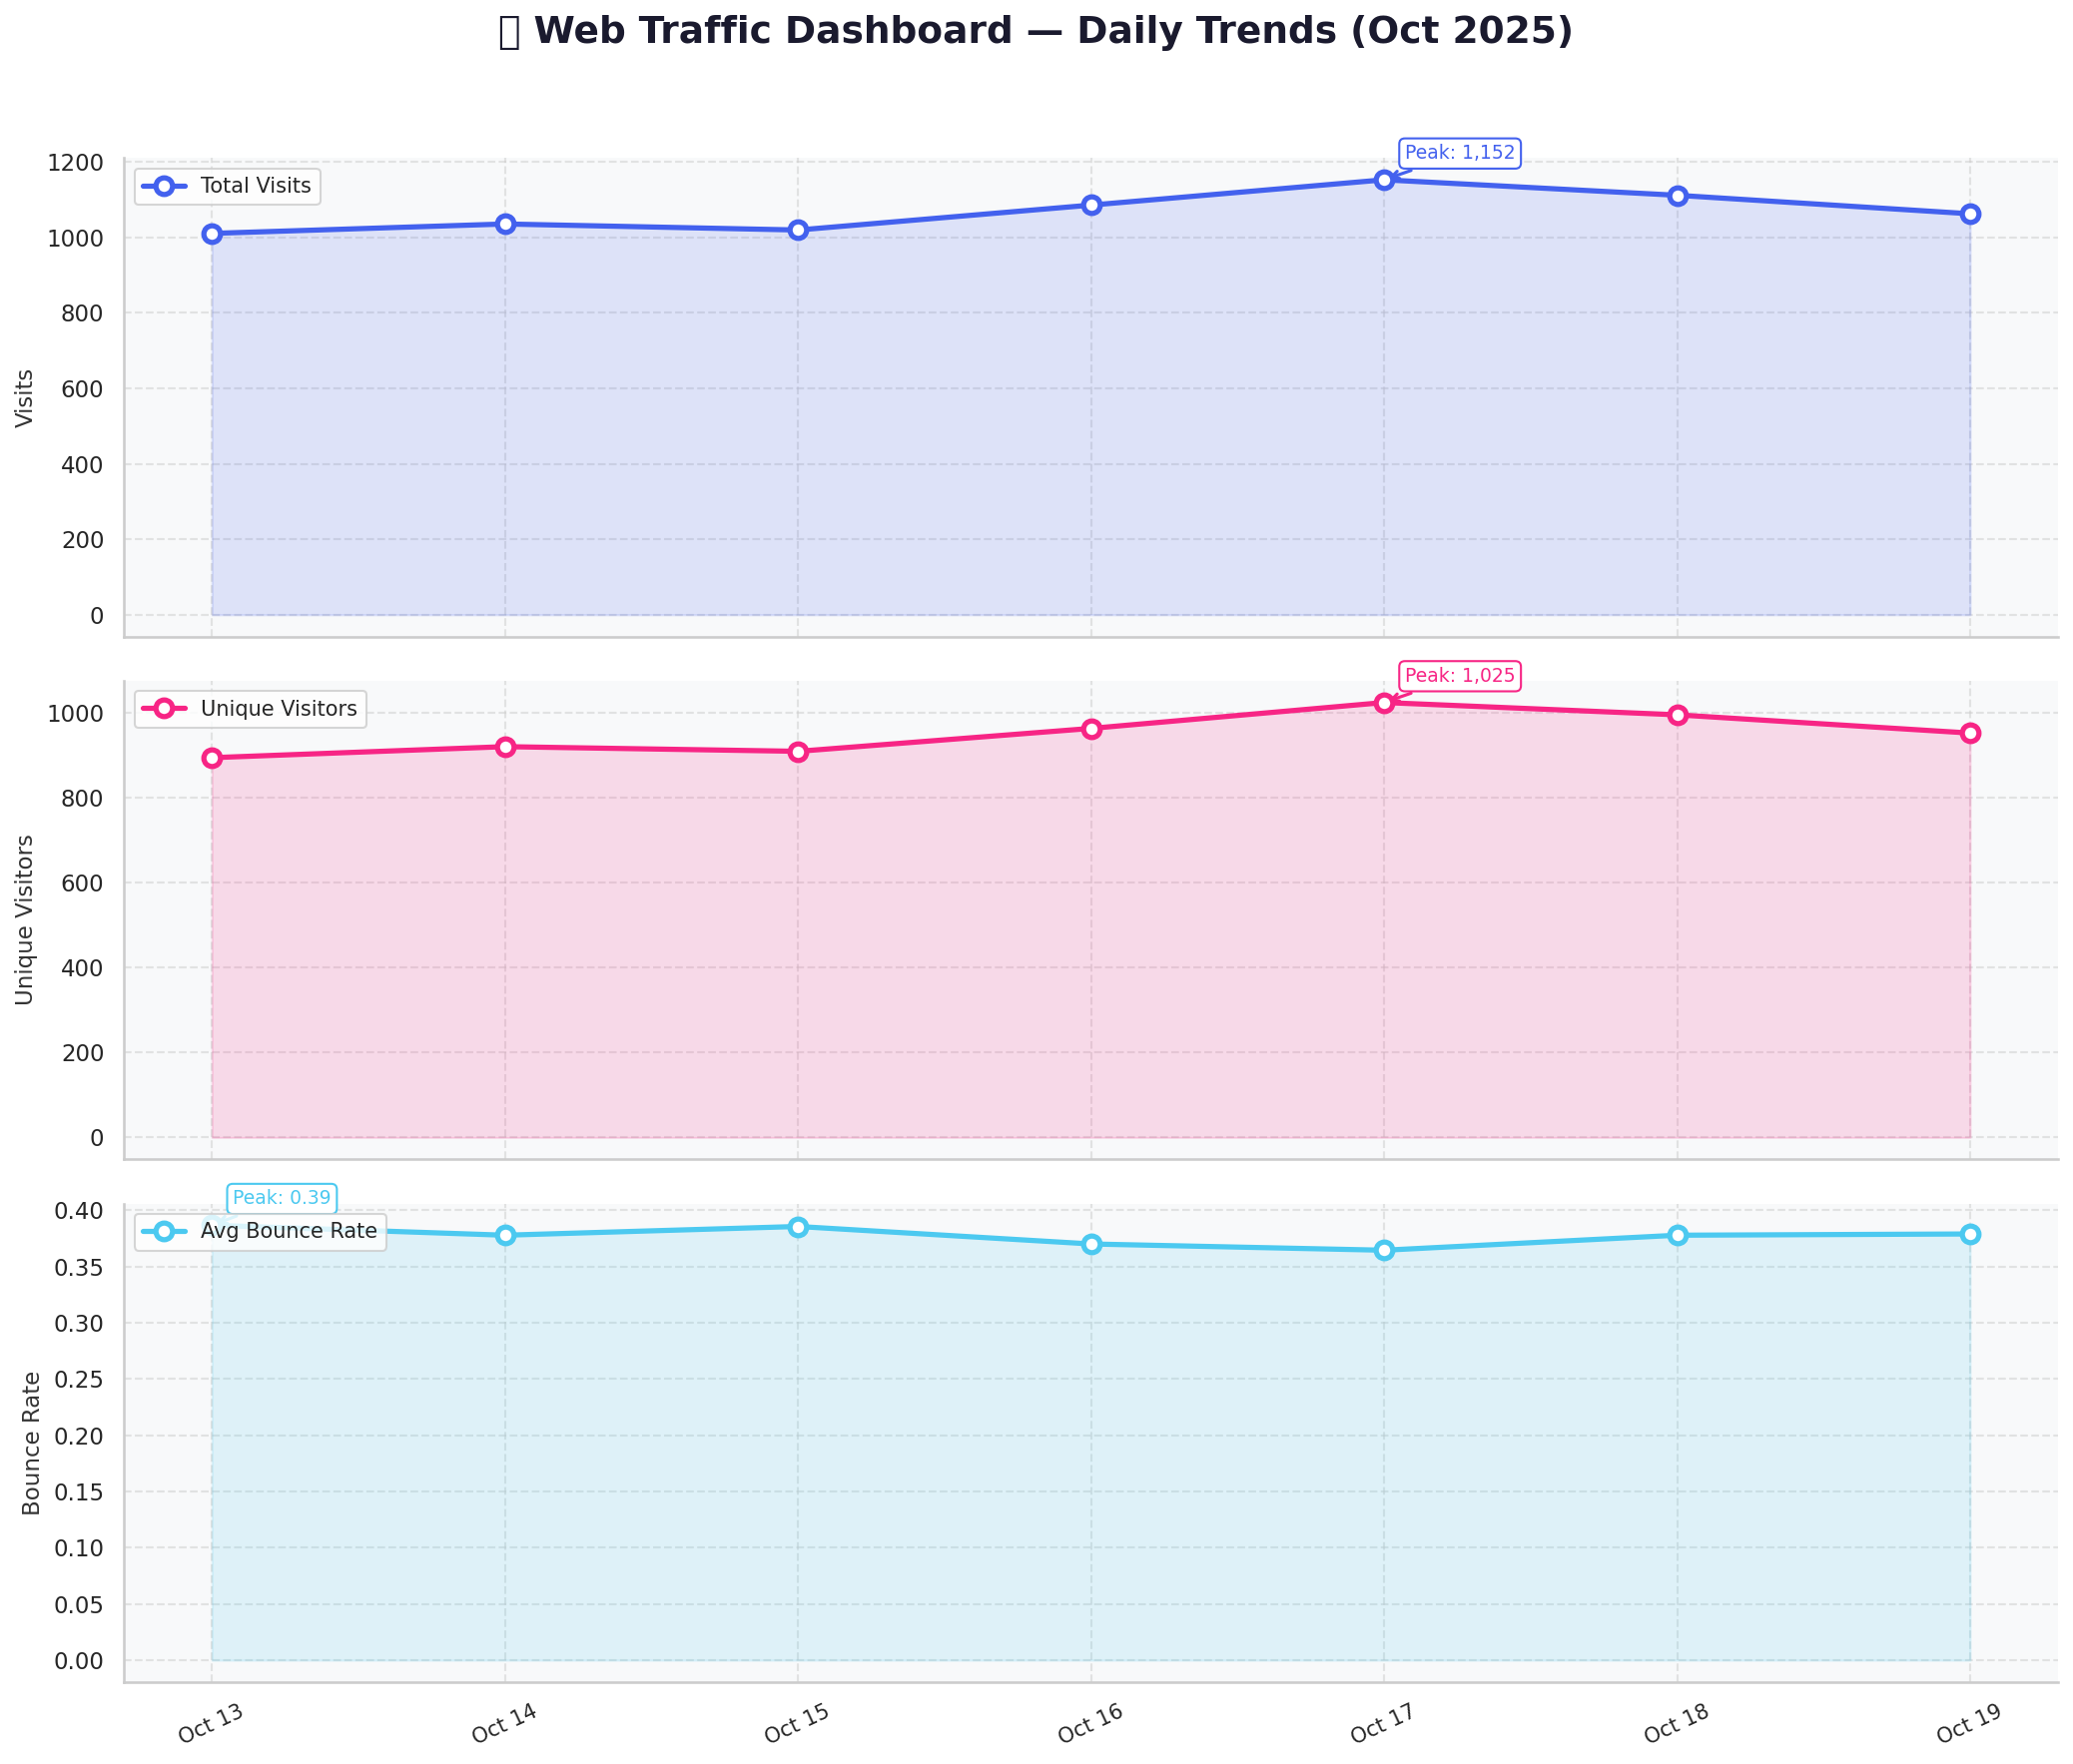

✅ Chart saved as 'traffic_trend_matplotlib.png'


In [5]:
# ============================================================
#  📈 CELL 4: Traffic Trend Over Time — Matplotlib
#
#  Chapter One of our story:
#  "How did our website traffic behave over the week?"
#
#  This is the heartbeat of the website — each rise and fall
#  tells us something about user behaviour and content impact.
# ============================================================

# Aggregate daily totals
daily = df.groupby('date').agg(
    total_visits=('visits', 'sum'),
    total_unique=('unique_visitors', 'sum'),
    avg_bounce=('bounce_rate', 'mean')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    "🌐 Web Traffic Dashboard — Daily Trends (Oct 2025)",
    fontsize=18, fontweight='bold', color='#1a1a2e', y=0.98
)

colors = ['#4361ee', '#f72585', '#4cc9f0']
labels = ['Total Visits', 'Unique Visitors', 'Avg Bounce Rate']
columns = ['total_visits', 'total_unique', 'avg_bounce']
ylabels = ['Visits', 'Unique Visitors', 'Bounce Rate']

for i, (ax, col, color, label, ylabel) in enumerate(
        zip(axes, columns, colors, labels, ylabels)):

    ax.plot(daily['date'], daily[col], color=color,
            linewidth=2.5, marker='o', markersize=8,
            markerfacecolor='white', markeredgewidth=2.5,
            markeredgecolor=color, label=label, zorder=5)

    ax.fill_between(daily['date'], daily[col], alpha=0.15, color=color)

    # Annotate peak
    peak_idx = daily[col].idxmax()
    peak_val = daily[col].max()
    peak_date = daily['date'][peak_idx]
    ax.annotate(f"Peak: {peak_val:.2f}" if col == 'avg_bounce' else f"Peak: {int(peak_val):,}",
                xy=(peak_date, peak_val),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1))

    ax.set_ylabel(ylabel, fontsize=11, color='#333')
    ax.set_facecolor('#f8f9fa')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[2].xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=25, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("traffic_trend_matplotlib.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved as 'traffic_trend_matplotlib.png'")

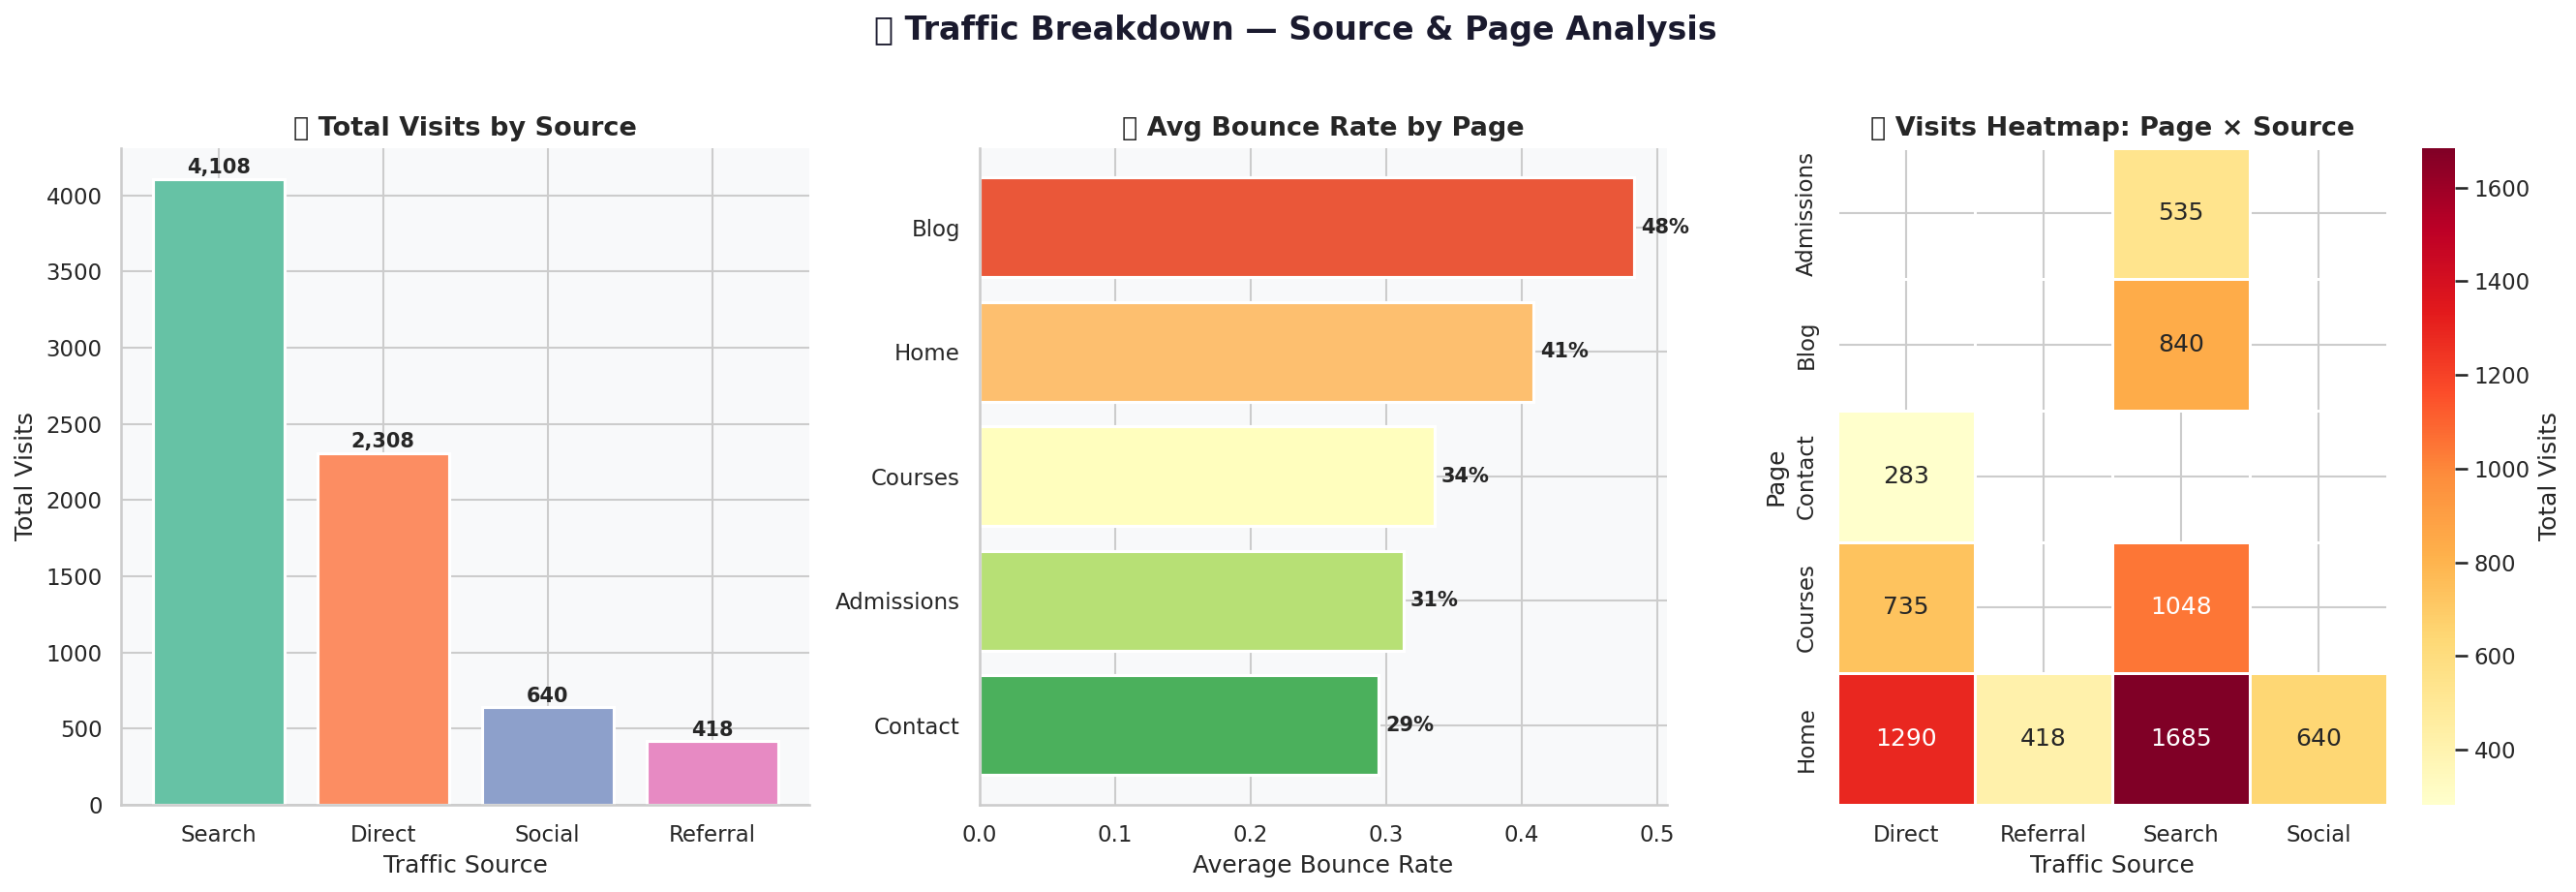

✅ Chart saved as 'traffic_source_page.png'


In [6]:
# ============================================================
#  🎨 CELL 5: Traffic by Source & Page — Seaborn
#
#  Chapter Two: "Where are our visitors coming from?"
#
#  Not all traffic is equal. Search engines bring researchers,
#  Social brings curious scrollers, Direct brings loyal fans.
#  Let's see which channels are powering this website.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "🔍 Traffic Breakdown — Source & Page Analysis",
    fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02
)

# --- Plot 1: Total Visits by Source ---
source_totals = df.groupby('source')['visits'].sum().sort_values(ascending=False).reset_index()
palette1 = sns.color_palette("Set2", len(source_totals))
bars = axes[0].bar(source_totals['source'], source_totals['visits'],
                   color=palette1, edgecolor='white', linewidth=1.5)
axes[0].set_title("📡 Total Visits by Source", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Traffic Source")
axes[0].set_ylabel("Total Visits")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot 2: Bounce Rate by Page (Horizontal) ---
page_bounce = df.groupby('page')['bounce_rate'].mean().sort_values().reset_index()
palette2 = sns.color_palette("RdYlGn_r", len(page_bounce))
hbars = axes[1].barh(page_bounce['page'], page_bounce['bounce_rate'],
                      color=palette2, edgecolor='white', linewidth=1.5)
axes[1].set_title("📉 Avg Bounce Rate by Page", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Average Bounce Rate")
for bar in hbars:
    axes[1].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.0%}',
                 va='center', fontsize=10, fontweight='bold')
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)

# --- Plot 3: Heatmap — Visits by Page & Source ---
pivot = df.pivot_table(values='visits', index='page', columns='source', aggfunc='sum')
sns.heatmap(pivot, ax=axes[2], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Total Visits'})
axes[2].set_title("🔥 Visits Heatmap: Page × Source", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Traffic Source")
axes[2].set_ylabel("Page")

plt.tight_layout()
plt.savefig("traffic_source_page.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved as 'traffic_source_page.png'")

In [7]:
# ============================================================
#  🚀 CELL 6: Interactive Dashboard — Plotly
#
#  Chapter Three: "Bringing the data to LIFE!"
#
#  Static charts tell a story. Interactive charts let YOU
#  explore that story. Hover, click, zoom — this is where
#  Python visualization truly becomes powerful.
# ============================================================

# Aggregate data
daily = df.groupby('date').agg(
    total_visits=('visits', 'sum'),
    total_unique=('unique_visitors', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    engagement=('engagement_score', 'sum')
).reset_index()

source_day = df.groupby(['date', 'source'])['visits'].sum().reset_index()
page_summary = df.groupby('page').agg(
    visits=('visits', 'sum'),
    unique=('unique_visitors', 'sum'),
    bounce=('bounce_rate', 'mean')
).reset_index()

# Build multi-panel dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "📈 Daily Visits vs Unique Visitors",
        "📊 Visits by Source Over Time",
        "🍩 Page Share of Total Traffic",
        "🌡️ Bounce Rate vs Engagement by Page"
    ),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "pie"}, {"type": "scatter"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# --- Panel 1: Line chart ---
fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['total_visits'],
    mode='lines+markers', name='Total Visits',
    line=dict(color='#4361ee', width=3),
    marker=dict(size=8, symbol='circle'),
    hovertemplate="<b>%{x}</b><br>Visits: %{y:,}<extra></extra>"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily['date'], y=daily['total_unique'],
    mode='lines+markers', name='Unique Visitors',
    line=dict(color='#f72585', width=3, dash='dot'),
    marker=dict(size=8, symbol='diamond'),
    hovertemplate="<b>%{x}</b><br>Unique: %{y:,}<extra></extra>"
), row=1, col=1)

# --- Panel 2: Stacked area by source ---
source_colors = {'Direct': '#4cc9f0', 'Search': '#4361ee',
                 'Social': '#f72585', 'Referral': '#7209b7'}
for src in source_day['source'].unique():
    src_data = source_day[source_day['source'] == src]
    fig.add_trace(go.Scatter(
        x=src_data['date'], y=src_data['visits'],
        mode='lines+markers', name=src,
        stackgroup='one',
        line=dict(color=source_colors.get(src, '#888')),
        hovertemplate=f"<b>{src}</b><br>Date: %{{x}}<br>Visits: %{{y:,}}<extra></extra>"
    ), row=1, col=2)

# --- Panel 3: Pie chart ---
fig.add_trace(go.Pie(
    labels=page_summary['page'],
    values=page_summary['visits'],
    hole=0.45,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Bold),
    hovertemplate="<b>%{label}</b><br>Visits: %{value:,}<br>Share: %{percent}<extra></extra>"
), row=2, col=1)

# --- Panel 4: Bubble chart ---
fig.add_trace(go.Scatter(
    x=page_summary['bounce'],
    y=page_summary['unique'],
    mode='markers+text',
    text=page_summary['page'],
    textposition='top center',
    marker=dict(
        size=page_summary['visits'] / 20,
        color=page_summary['bounce'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title="Bounce Rate", x=1.02),
        line=dict(width=1, color='white')
    ),
    name='Pages',
    hovertemplate="<b>%{text}</b><br>Bounce: %{x:.0%}<br>Unique: %{y:,}<extra></extra>"
), row=2, col=2)

# Layout
fig.update_layout(
    title=dict(
        text="🌐 <b>WebTraffic Interactive Analytics Dashboard</b><br>"
             "<sup>Powered by Python + Plotly | October 2025</sup>",
        font=dict(size=20, color='#1a1a2e'),
        x=0.5, xanchor='center'
    ),
    height=750,
    paper_bgcolor='#f0f2f5',
    plot_bgcolor='white',
    legend=dict(
        orientation='h',
        yanchor='bottom', y=-0.15,
        xanchor='center', x=0.5
    ),
    font=dict(family='Arial', size=11),
    margin=dict(t=100, b=80, l=60, r=80)
)

fig.update_xaxes(showgrid=True, gridcolor='#e0e0e0')
fig.update_yaxes(showgrid=True, gridcolor='#e0e0e0')

fig.show()
fig.write_html("webtraffic_interactive_dashboard.html")
print("✅ Interactive dashboard saved as 'webtraffic_interactive_dashboard.html'")

✅ Interactive dashboard saved as 'webtraffic_interactive_dashboard.html'


In [8]:
# ============================================================
#  📄 CELL 7: Automated PDF Report Generation
#
#  The Final Chapter: "Telling the full story in print."
#
#  A manager shouldn't need to run code to understand results.
#  We automate a beautiful PDF report - a document that walks
#  any reader through our findings with clarity and confidence.
# ============================================================

from fpdf import FPDF
from datetime import datetime

class WebTrafficReport(FPDF):
    def header(self):
        self.set_fill_color(26, 26, 46)       # Dark navy
        self.rect(0, 0, 210, 22, 'F')
        self.set_text_color(255, 255, 255)
        self.set_font("Helvetica", "B", 14)
        self.set_y(6)
        self.cell(0, 10, "  WEB TRAFFIC ANALYTICS REPORT  |  October 2025", ln=True, align='C') # Removed 🌐 emoji
        self.set_text_color(0, 0, 0)
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_fill_color(26, 26, 46)
        self.rect(0, 282, 210, 15, 'F')
        self.set_text_color(200, 200, 200)
        self.set_font("Helvetica", "I", 8)
        self.set_y(-12)
        self.cell(0, 10,
                  f"  Generated by Python | {datetime.now().strftime('%d %B %Y, %H:%M')}  |  Page {self.page_no()}",
                  align='C')

    def section_title(self, title, color=(67, 97, 238)):
        self.set_fill_color(*color)
        self.set_text_color(255, 255, 255)
        self.set_font("Helvetica", "B", 12)
        self.cell(0, 9, f"  {title}", ln=True, fill=True)
        self.set_text_color(0, 0, 0)
        self.ln(2)

    def body_text(self, text):
        self.set_font("Helvetica", "", 10)
        self.set_text_color(50, 50, 50)
        self.multi_cell(0, 6, text)
        self.ln(2)

    def kpi_box(self, label, value, color=(67, 97, 238)):
        r, g, b = color
        self.set_fill_color(r, g, b)
        self.set_text_color(255, 255, 255)
        self.set_font("Helvetica", "B", 11)
        self.cell(62, 12, f" {label}", fill=True)
        self.set_fill_color(240, 242, 245)
        self.set_text_color(26, 26, 46)
        self.set_font("Helvetica", "B", 14)
        self.cell(0, 12, f"  {value}", fill=True, ln=True)
        self.ln(1)


# ---- Build Report ----
pdf = WebTrafficReport()
pdf.set_auto_page_break(auto=True, margin=20)
pdf.add_page()

# --- Executive Summary ---
pdf.section_title("Executive Summary") # Removed 📋 emoji
pdf.body_text(
    "This report presents a comprehensive analysis of web traffic data collected across seven days "
    "in October 2025. The data captures visitor behaviour across five key pages - Home, Courses, "
    "Blog, Contact, and Admissions - through four traffic sources: Direct, Search, Social, and Referral.\n\n"
    "Our analysis reveals clear patterns in how users discover and engage with the website. "
    "Search remains the dominant driver of traffic, while Direct visits signal a loyal returning audience. "
    "Bounce rate analysis highlights the Blog as the most challenging page for retention, "
    "whereas the Contact and Admissions pages demonstrate strong visitor intent and engagement."
)

# --- KPIs ---
daily_kpi = df.groupby('date').agg(
    total_visits=('visits','sum'),
    unique=('unique_visitors','sum'),
    bounce=('bounce_rate','mean')
).reset_index()

pdf.section_title("Key Performance Indicators", color=(247, 37, 133)) # Removed 📊 emoji

pdf.kpi_box("Total Visits (Week)", f"{df['visits'].sum():,}", (67, 97, 238))
pdf.kpi_box("Total Unique Visitors", f"{df['unique_visitors'].sum():,}", (76, 201, 240))
pdf.kpi_box("Avg Daily Visits", f"{daily_kpi['total_visits'].mean():,.0f}", (114, 9, 183))
pdf.kpi_box("Avg Bounce Rate", f"{df['bounce_rate'].mean():.1%}", (247, 37, 133))
pdf.kpi_box("Peak Day Visits", f"{daily_kpi['total_visits'].max():,}", (67, 97, 238))
pdf.kpi_box("Best Bounce Rate Page",
            df.groupby('page')['bounce_rate'].mean().idxmin(), (76, 201, 240))

# --- Charts ---
pdf.ln(3)
pdf.section_title("Traffic Trend - Daily Overview") # Removed 📈 emoji
pdf.body_text(
    "The chart below shows the day-by-day movement of total visits and unique visitors. "
    "Friday (Oct 17) recorded the highest traffic, suggesting either a content release or "
    "marketing campaign effect. The close tracking between total and unique visitors "
    "indicates low repeat-visit behaviour - a growth opportunity."
)
if os.path.exists("traffic_trend_matplotlib.png"):
    pdf.image("traffic_trend_matplotlib.png", x=10, w=185)
pdf.ln(4)

pdf.add_page()
pdf.section_title("Traffic by Source & Page") # Removed 🔍 emoji
pdf.body_text(
    "Breaking down visits by source reveals that Search traffic dominates across all pages. "
    "The heatmap shows that the Home page captures the broadest cross-channel audience, "
    "while Blog and Courses are almost exclusively reached through Search. "
    "Social media drives moderate Home page traffic but has limited reach to inner pages - "
    "an area for strategic improvement."
)
if os.path.exists("traffic_source_page.png"):
    pdf.image("traffic_source_page.png", x=10, w=185)

# --- Top Pages Table ---
pdf.ln(4)
pdf.section_title("Top Pages by Total Visits") # Removed 🏆 emoji
page_table = df.groupby('page').agg(
    Total_Visits=('visits','sum'),
    Unique_Visitors=('unique_visitors','sum'),
    Avg_Bounce=('bounce_rate','mean')
).sort_values('Total_Visits', ascending=False).reset_index()

pdf.set_font("Helvetica", "B", 10)
pdf.set_fill_color(26, 26, 46)
pdf.set_text_color(255, 255, 255)
for col, w in zip(['Page', 'Total Visits', 'Unique Visitors', 'Avg Bounce Rate'],
                  [55, 45, 50, 45]):
    pdf.cell(w, 8, col, border=1, fill=True, align='C')
pdf.ln()

pdf.set_font("Helvetica", "", 10)
for i, row in page_table.iterrows():
    pdf.set_fill_color(240, 242, 245) if i % 2 == 0 else pdf.set_fill_color(255, 255, 255)
    pdf.set_text_color(50, 50, 50)
    pdf.cell(55, 7, str(row['page']), border=1, fill=True, align='C')
    pdf.cell(45, 7, f"{row['Total_Visits']:,}", border=1, fill=True, align='C')
    pdf.cell(50, 7, f"{row['Unique_Visitors']:,}", border=1, fill=True, align='C')
    pdf.cell(45, 7, f"{row['Avg_Bounce']:.1%}", border=1, fill=True, align='C')
    pdf.ln()

# --- Recommendations ---
pdf.ln(4)
pdf.section_title("Recommendations & Next Steps", color=(114, 9, 183)) # Removed 💡 emoji
recommendations = [
    "1. BOOST SOCIAL TRAFFIC: Social media only reaches the Home page. Create shareable links to Courses and Blog to expand reach.",
    "2. REDUCE BLOG BOUNCE RATE: At 48-50%, the Blog has the highest bounce rate. Add related content links, stronger CTAs, and internal navigation.",
    "3. CAPITALISE ON SEARCH DOMINANCE: Search drives the most visits. Invest in SEO for Admissions and Courses pages to convert high-intent visitors.",
    "4. GROW REFERRAL CHANNEL: Referral traffic is the smallest source. Build partnerships and backlinks to diversify the traffic mix.",
    "5. MONITOR PEAK DAYS: Friday spikes suggest responsiveness to campaigns. Schedule key content releases and promotions for Thursdays to maximise Friday peaks."
]
for rec in recommendations:
    pdf.body_text(rec)

# Save
pdf.output("WebTraffic_Automated_Report.pdf")
print("✅ PDF Report saved as 'WebTraffic_Automated_Report.pdf'")

✅ PDF Report saved as 'WebTraffic_Automated_Report.pdf'


In [9]:
# ============================================================
#  🌍 CELL 8: Export HTML Report & Download Everything
#
#  Epilogue: "Delivering the story to the world."
#
#  We package everything into a polished HTML report
#  and provide download links for all outputs.
#  The audience gets the PDF for print, the HTML for web,
#  and the interactive dashboard for exploration.
# ============================================================

# --- Build HTML Report ---
daily_html = df.groupby('date').agg(
    total_visits=('visits','sum'),
    total_unique=('unique_visitors','sum'),
    avg_bounce=('bounce_rate','mean')
).reset_index()

page_html = df.groupby('page').agg(
    visits=('visits','sum'),
    unique=('unique_visitors','sum'),
    bounce=('bounce_rate','mean')
).sort_values('visits', ascending=False).reset_index()

rows_html = ""
for _, row in page_html.iterrows():
    rows_html += f"""
    <tr>
      <td>{row['page']}</td>
      <td>{row['visits']:,}</td>
      <td>{row['unique']:,}</td>
      <td>{row['bounce']:.1%}</td>
    </tr>"""

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Web Traffic Analytics Report</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 0; background: #f0f2f5; color: #1a1a2e; }}
  .header {{ background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
             color: white; padding: 40px; text-align: center; }}
  .header h1 {{ margin: 0; font-size: 2.2em; }}
  .header p {{ margin: 8px 0 0; opacity: 0.8; font-size: 1em; }}
  .container {{ max-width: 1100px; margin: 30px auto; padding: 0 20px; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(3, 1fr); gap: 16px; margin: 24px 0; }}
  .kpi-card {{ background: white; border-radius: 12px; padding: 20px;
               box-shadow: 0 4px 15px rgba(0,0,0,0.08); border-top: 4px solid #4361ee; }}
  .kpi-card h3 {{ margin: 0 0 8px; font-size: 0.85em; color: #888; text-transform: uppercase; }}
  .kpi-card .value {{ font-size: 2em; font-weight: bold; color: #1a1a2e; }}
  .section {{ background: white; border-radius: 12px; padding: 28px;
              box-shadow: 0 4px 15px rgba(0,0,0,0.08); margin-bottom: 24px; }}
  .section h2 {{ color: #4361ee; border-bottom: 2px solid #e0e7ff; padding-bottom: 10px; }}
  table {{ width: 100%; border-collapse: collapse; margin-top: 12px; }}
  th {{ background: #1a1a2e; color: white; padding: 10px 14px; text-align: left; }}
  td {{ padding: 9px 14px; border-bottom: 1px solid #e0e7ff; }}
  tr:nth-child(even) {{ background: #f8f9ff; }}
  tr:hover {{ background: #e0e7ff; }}
  .rec-list li {{ margin-bottom: 10px; line-height: 1.6; }}
  .footer {{ text-align: center; padding: 20px; color: #888; font-size: 0.85em; }}
  .tag {{ display: inline-block; background: #e0e7ff; color: #4361ee;
          border-radius: 20px; padding: 3px 12px; font-size: 0.8em; margin: 2px; }}
</style>
</head>
<body>
<div class="header">
  <h1>🌐 Web Traffic Analytics Report</h1>
  <p>October 2025 &nbsp;|&nbsp; Generated by Python &nbsp;|&nbsp; {datetime.now().strftime('%d %B %Y')}</p>
  <br>
  <span class="tag">matplotlib</span>
  <span class="tag">seaborn</span>
  <span class="tag">plotly</span>
  <span class="tag">pandas</span>
  <span class="tag">fpdf2</span>
</div>

<div class="container">
  <div class="kpi-grid">
    <div class="kpi-card">
      <h3>Total Visits</h3>
      <div class="value">{df['visits'].sum():,}</div>
    </div>
    <div class="kpi-card" style="border-color:#f72585">
      <h3>Unique Visitors</h3>
      <div class="value">{df['unique_visitors'].sum():,}</div>
    </div>
    <div class="kpi-card" style="border-color:#4cc9f0">
      <h3>Avg Bounce Rate</h3>
      <div class="value">{df['bounce_rate'].mean():.1%}</div>
    </div>
    <div class="kpi-card" style="border-color:#7209b7">
      <h3>Avg Daily Visits</h3>
      <div class="value">{daily_html['total_visits'].mean():,.0f}</div>
    </div>
    <div class="kpi-card" style="border-color:#f72585">
      <h3>Top Traffic Source</h3>
      <div class="value" style="font-size:1.4em">{df.groupby('source')['visits'].sum().idxmax()}</div>
    </div>
    <div class="kpi-card" style="border-color:#4361ee">
      <h3>Best Bounce Page</h3>
      <div class="value" style="font-size:1.4em">{df.groupby('page')['bounce_rate'].mean().idxmin()}</div>
    </div>
  </div>

  <div class="section">
    <h2>📋 Executive Summary</h2>
    <p>This report analyses seven days of web traffic data across five pages and four traffic sources.
    Search traffic dominates, Friday recorded peak visits, and the Contact page shows the strongest
    visitor intent with the lowest bounce rate. Python automation was used end-to-end — from
    data cleaning to this very report.</p>
  </div>

  <div class="section">
    <h2>🏆 Page Performance Summary</h2>
    <table>
      <thead><tr><th>Page</th><th>Total Visits</th><th>Unique Visitors</th><th>Avg Bounce Rate</th></tr></thead>
      <tbody>{rows_html}</tbody>
    </table>
  </div>

  <div class="section">
    <h2>💡 Recommendations</h2>
    <ol class="rec-list">
      <li><strong>Boost Social Traffic:</strong> Social only reaches the Home page. Create shareable links to inner pages.</li>
      <li><strong>Reduce Blog Bounce Rate:</strong> At ~49%, add related content, CTAs, and internal links.</li>
      <li><strong>Capitalise on Search Dominance:</strong> Invest in SEO for Admissions and Courses pages.</li>
      <li><strong>Grow Referral Channel:</strong> Build backlinks and partnerships to diversify traffic sources.</li>
      <li><strong>Leverage Friday Peaks:</strong> Schedule content releases on Thursdays to maximise weekend traffic.</li>
    </ol>
  </div>
</div>
<div class="footer">Python for Visualization & Reporting &nbsp;|&nbsp; Group Project &nbsp;|&nbsp; October 2025</div>
</body>
</html>"""

with open("WebTraffic_Report.html", "w") as f:
    f.write(html_content)

print("✅ HTML Report saved as 'WebTraffic_Report.html'")

# --- Download all files ---
print("\n" + "="*60)
print("       📦 DOWNLOADING ALL OUTPUT FILES")
print("="*60)

output_files = [
    "WebTraffic_Automated_Report.pdf",
    "WebTraffic_Report.html",
    "webtraffic_interactive_dashboard.html",
    "traffic_trend_matplotlib.png",
    "traffic_source_page.png"
]

from google.colab import files
for fname in output_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f"  ⬇️  Downloaded: {fname}")
    else:
        print(f"  ⚠️  Not found: {fname} — run previous cells first")

print("\n🎉 ALL DONE! Your Web Traffic Analysis is complete.")
print("📂 Files ready: PDF Report, HTML Report, Interactive Dashboard, PNG Charts")

✅ HTML Report saved as 'WebTraffic_Report.html'

       📦 DOWNLOADING ALL OUTPUT FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: WebTraffic_Automated_Report.pdf


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: traffic_trend_matplotlib.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: traffic_source_page.png

🎉 ALL DONE! Your Web Traffic Analysis is complete.
📂 Files ready: PDF Report, HTML Report, Interactive Dashboard, PNG Charts
